In [2]:
import numpy as np
from tensorflow import keras
from keras.datasets import mnist
from keras.models import Sequential
import matplotlib.pyplot as plt
from keras.utils import to_categorical

In [3]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [4]:
x_train.shape

(60000, 28, 28)

Label: 0


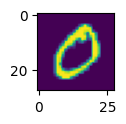

In [5]:
plt.figure(figsize=(1,1))
index = 1
plt.imshow(x_train[index])
print(f'Label: {y_train[index]}')

In [6]:
# load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# pixels are in range 0 to 255, by dividing it comes in 0 to 1
img_train = x_train/255
img_test = x_test/255

# convert lables to categorial data
lbl_train = to_categorical(y_train, 10)
lbl_test = to_categorical(y_test, 10)

num_samples_train, img_rows, img_cols = img_train.shape
img_train = img_train.reshape(num_samples_train, img_rows*img_cols)

num_samples_test, img_rows, img_cols = img_test.shape
img_test = img_test.reshape(num_samples_test, img_rows*img_cols)

# create model
model = keras.Sequential([
    keras.layers.Input(shape=(img_rows*img_cols, )),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

# compile and fit
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(img_train, lbl_train, epochs=16, batch_size=16, validation_split=0.2)

Epoch 1/16
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9260 - loss: 0.2559 - val_accuracy: 0.9608 - val_loss: 0.1350
Epoch 2/16
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9669 - loss: 0.1118 - val_accuracy: 0.9667 - val_loss: 0.1088
Epoch 3/16
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9770 - loss: 0.0758 - val_accuracy: 0.9710 - val_loss: 0.0974
Epoch 4/16
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9823 - loss: 0.0569 - val_accuracy: 0.9739 - val_loss: 0.0895
Epoch 5/16
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9863 - loss: 0.0428 - val_accuracy: 0.9753 - val_loss: 0.0900
Epoch 6/16
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9892 - loss: 0.0334 - val_accuracy: 0.9743 - val_loss: 0.0953
Epoch 7/16
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9918 - loss: 0.0262 - val_accuracy: 0.9764 - val_loss: 0.0940
Epoch 8/16
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9926 - loss: 0.0213 - 

In [8]:
evaluation = model.evaluate(img_test, lbl_test)
evaluation

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9792 - loss: 0.1011


[0.1010986715555191, 0.979200005531311]

In [9]:
prediction = model.predict(img_test[:20,:])
print(prediction.argmax(1))
print(y_test[:20])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
[7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]
[7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]
